## AI Agent to Master a Game: Taxi with Q-Learning

This project builds an AI agent that learns to play a game by itself with reinforcement learning. The agent does not know the rules. It only sees the state of the game and the reward after each action, and it learns by trial and error. We use the Taxi game from the Gymnasium library (the successor of OpenAI Gym): a taxi has to pick up a passenger and drop them at the right place. The objective is in order to train an agent that delivers the passenger quickly and without mistakes, and show that it is much better than an agent that acts randomly.

## Approach
1. Set up the game and explore the states, actions, and rewards
2. Measure a random agent as a baseline
3. Train a Q-learning agent (a Q-table with epsilon-greedy exploration)
4. Plot the learning curve (reward per episode)
5. Evaluate the trained agent and compare it with the random agent
6. Test how the number of training episodes and the learning settings change the result
7. Watch the trained agent play a full game
8. Publish as Streamlit app

In [1]:
# Set up the game
import numpy as np, pandas as pd, gymnasium as gym
import matplotlib.pyplot as plt

env_name = "Taxi-v4" if "Taxi-v4" in gym.registry else "Taxi-v3"
env = gym.make(env_name, render_mode="ansi")

In [2]:
print(env_name, env.observation_space, env.action_space)

Taxi-v4 Discrete(500) Discrete(6)


In [3]:
state, info = env.reset(seed=7)
print(state)
print(env.render())

309
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




In [4]:
state, reward, terminated, truncated, info = env.step(0)                # 0 = güneye git
print(state, reward, terminated)                                        # yeni durum, ödül (-1), bitti mi

409 -1 False


In [5]:
# Measure a random agent
def evaluate(policy, n=200):
    results = []
    for i in range(n):
        state, _ = env.reset(seed=i)
        total, steps, done = 0, 0, False
        while not done:
            state, reward, terminated, truncated, _ = env.step(policy(state))
            total += reward
            steps += 1
            done = terminated or truncated
        results.append({"reward": total, "steps": steps, "success": terminated})
    return pd.DataFrame(results).mean().round(2)

evaluate(lambda s: env.action_space.sample())

,0
reward,-770.56
steps,197.06
success,0.04


In [7]:
def train(episodes=5000, alpha=0.1, gamma=0.99, eps=1.0, eps_min=0.05, decay=0.999, seed=42):
    rng = np.random.default_rng(seed)
    Q = np.zeros((500, 6))                               # Q-tablosu: her (durum, eylem) için beklenen toplam ödül
    rewards = []
    for ep in range(episodes):
        state, _ = env.reset(seed=int(rng.integers(1e9)))
        total, done = 0, False
        while not done:
            if rng.random() < eps:
                action = int(rng.integers(6))            # keşfet: rastgele eylem
            else:
                action = int(Q[state].argmax())          # sömür: bildiği en iyi eylem
            new_state, reward, terminated, truncated, _ = env.step(action)
            best_next = 0 if terminated else Q[new_state].max()
            Q[state, action] += alpha * (reward + gamma * best_next - Q[state, action])     # öğrenme adımı
            state, total, done = new_state, total + reward, terminated or truncated
        eps = max(eps_min, eps * decay)                  # zamanla keşfi azalt
        rewards.append(total)
    return Q, np.array(rewards)

In [8]:
Q, rewards = train()
print(Q.shape)
print(rewards[:100].mean().round(0), rewards[-100:].mean().round(1))

(500, 6)
-757.0 4.7


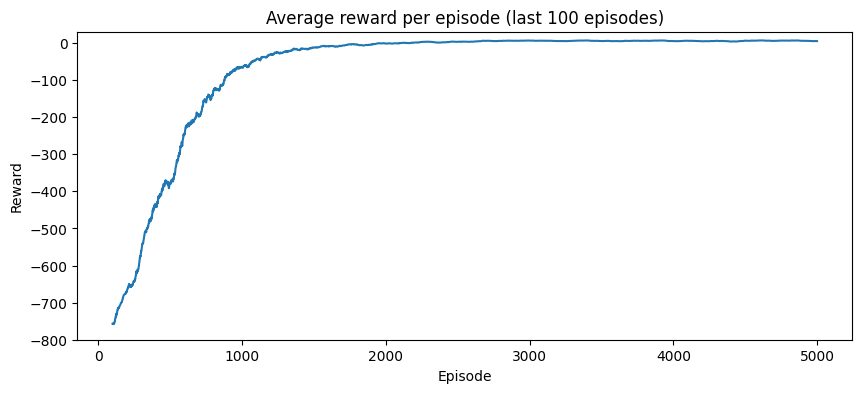

In [10]:
# Plot the learning curve
pd.Series(rewards).rolling(100).mean().plot(figsize=(10, 4), title="Average reward per episode (last 100 episodes)")
plt.xlabel("Episode"); plt.ylabel("Reward"); plt.ylim(-800, 30); plt.show()

In [11]:
evaluate(lambda s: int(Q[s].argmax()))

,0
reward,7.62
steps,13.38
success,1.00


In [13]:
# Train duration
Qs = {n: train(episodes=n)[0] for n in [500, 1000, 2000, 5000]}
pd.DataFrame({f"{n} episodes": evaluate(lambda s, Qn=Qn: int(Qn[s].argmax())) for n, Qn in Qs.items()}).T

,reward,steps,success
500 episodes,-187.20,188.46,0.06
1000 episodes,-138.95,145.04,0.29
2000 episodes,-17.95,36.33,0.88
5000 episodes,7.62,13.38,1.00


In [14]:
# Settings
settings = {"default": {}, "alpha 0.01": {"alpha": 0.01}, "alpha 0.5": {"alpha": 0.5}, "gamma 0.5": {"gamma": 0.5}}
pd.DataFrame({n: evaluate(lambda s, Qn=train(**kw)[0]: int(Qn[s].argmax())) for n, kw in settings.items()}).T

,reward,steps,success
default,7.62,13.38,1.00
alpha 0.01,-178.76,180.86,0.10
alpha 0.5,7.58,13.42,1.00
gamma 0.5,-84.23,95.88,0.56


In [15]:
actions = ["south", "north", "east", "west", "pickup", "dropoff"]
state, _ = env.reset(seed=3)
frames, moves, total, done = [env.render()], [], 0, False
while not done:
    action = int(Q[state].argmax())
    state, reward, terminated, truncated, _ = env.step(action)
    moves.append(actions[action]); total += reward; frames.append(env.render()); done = terminated or truncated

print(len(moves), "steps, total reward", total)
print(moves)
print(frames[0]); print(frames[len(frames) // 2]); print(frames[-1])

12 steps, total reward 9
['south', 'south', 'west', 'west', 'north', 'north', 'pickup', 'south', 'south', 'south', 'south', 'dropoff']
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

